<a href="https://colab.research.google.com/github/kursatkara/MAE_5020_Spring_2026/blob/master/06_Notebook_D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Notebook D — Clean PyTorch Workflow: From Educational Example to Standard Practice

## 🎯 Learning Objective

Transition from hand-derived toy examples to a more standard neural-network workflow in PyTorch without losing the mathematical meaning of the model.

In this notebook, we will:

- define a model using `nn.Module`,
- separate model definition, training, and evaluation,
- normalize the inputs,
- use reproducible initialization,
- compare training and testing behavior in a clean workflow.

---

## 🧠 Challenge

In the first three notebooks, we intentionally used very small examples so that every step could be inspected.

That was the right way to build intuition.

However, real machine-learning workflows usually require better software structure:

- the model should be reusable,
- the training loop should be separated from the model,
- data preparation should be explicit,
- evaluation should be cleanly distinguished from training.

The challenge is therefore:

> How do we move to a more realistic PyTorch workflow **without turning the neural network into a black box**?



## 🔹 Conceptual Anchor

Even though the code will look cleaner in this notebook, the mathematical model is still the same basic idea:

$$
\hat{y} = f(x; \theta),
$$
where $\theta$ contains the trainable parameters of the neural network.

For a one-hidden-layer network, the structure is still

$$
z^1 = W^1 x + b^1,
$$
$$
a^1 = \phi(z^1),
$$
$$
\hat{y} = W^2 a^1 + b^2.
$$

The difference is that PyTorch now packages these operations inside modular software components.


In [8]:

import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(7)
np.random.seed(7)

plt.rcParams["figure.figsize"] = (7, 4)



## 🔹 Generate a Regression Dataset

We again study a noisy nonlinear regression problem:

$$
y = x^2 + \epsilon,
$$

where $\epsilon$ represents noise.

We keep the same general theme as Notebook C so that students can focus on the workflow changes rather than a completely new problem.


In [9]:

# Generate dataset
N = 40
x_all = torch.linspace(-1.5, 1.5, N).unsqueeze(1)
y_true_all = x_all**2
noise = 0.10 * torch.randn_like(x_all)
y_all = y_true_all + noise

# Reproducible train/test split
perm = torch.randperm(N)
train_idx = perm[:24]
test_idx = perm[24:]

x_train_raw = x_all[train_idx]
y_train = y_all[train_idx]

x_test_raw = x_all[test_idx]
y_test = y_all[test_idx]

def sort_xy(x, y):
    idx = torch.argsort(x[:, 0])
    return x[idx], y[idx]

x_train_raw, y_train = sort_xy(x_train_raw, y_train)
x_test_raw, y_test = sort_xy(x_test_raw, y_test)
x_all_sorted, y_all_sorted = sort_xy(x_all, y_all)
_, y_true_sorted = sort_xy(x_all, y_true_all)

print("Training samples:", len(x_train_raw))
print("Testing samples :", len(x_test_raw))


Training samples: 24
Testing samples : 16


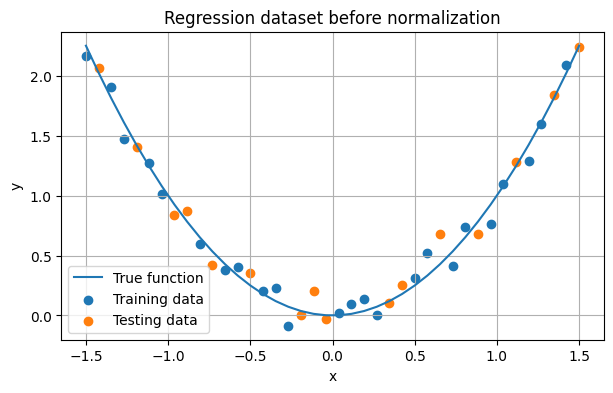

In [10]:

plt.figure()
plt.plot(x_all_sorted.numpy(), y_true_sorted.numpy(), label="True function")
plt.scatter(x_train_raw.numpy(), y_train.numpy(), label="Training data")
plt.scatter(x_test_raw.numpy(), y_test.numpy(), label="Testing data")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Regression dataset before normalization")
plt.legend()
plt.grid(True)
plt.show()



## 🔹 Why Normalize the Input?

In larger models and more realistic datasets, raw variables may have very different scales.

That can make optimization harder.

A standard practice is to normalize the input using the training set statistics:

$$
x_{\text{norm}} = \frac{x - \mu_{\text{train}}}{\sigma_{\text{train}}}.
$$

Important principle:

> The normalization parameters must be computed from the training data only.

This avoids leaking information from the test set into the training process.


In [11]:

# Normalize using training statistics only
x_mean = x_train_raw.mean(dim=0, keepdim=True)
x_std = x_train_raw.std(dim=0, keepdim=True)

x_train = (x_train_raw - x_mean) / x_std
x_test = (x_test_raw - x_mean) / x_std

print("Training mean after normalization:", x_train.mean().item())
print("Training std after normalization :", x_train.std().item())


Training mean after normalization: 1.9868215517249155e-08
Training std after normalization : 1.0



## 🔹 Defining the Model with `nn.Module`

This is a standard PyTorch pattern.

The point is not only to make the code look cleaner.  
The point is to **encapsulate the mathematical model** in a reusable class.

### Mapping from math to code

- first linear layer `fc1` corresponds to the affine map
  $$
  z^1 = W^1 x + b^1
  $$
- activation function corresponds to
  $$
  a^1 = \phi(z^1)
  $$
- second linear layer `fc2` maps hidden features to the scalar prediction
  $$
  \hat{y} = W^2 a^1 + b^2
  $$

This explicit mapping is important.  
Students should always be able to explain what each layer means mathematically.


In [12]:

class SimpleRegressor(torch.nn.Module):
    def __init__(self, hidden_width=10):
        super().__init__()
        self.fc1 = torch.nn.Linear(1, hidden_width)
        self.fc2 = torch.nn.Linear(hidden_width, 1)

    def forward(self, x):
        z1 = self.fc1(x)
        a1 = torch.tanh(z1)
        y_hat = self.fc2(a1)
        return y_hat



## 🔹 Inspecting the Model

Before training, it is useful to inspect the model and understand what PyTorch has created.

Notice that the trainable parameters are now organized inside the model object.


In [13]:

model = SimpleRegressor(hidden_width=10)
print(model)

print("Trainable parameters:")
for name, param in model.named_parameters():
    print(f"{name:15s} shape = {tuple(param.shape)}")


SimpleRegressor(
  (fc1): Linear(in_features=1, out_features=10, bias=True)
  (fc2): Linear(in_features=10, out_features=1, bias=True)
)
Trainable parameters:
fc1.weight      shape = (10, 1)
fc1.bias        shape = (10,)
fc2.weight      shape = (1, 10)
fc2.bias        shape = (1,)



## 🔹 Loss Function and Optimizer

For this regression problem, we use mean squared error:

$$
L(\theta) = \frac{1}{N}\sum_{i=1}^N \left(\hat{y}_i - y_i\right)^2.
$$

We will use stochastic gradient descent (SGD) as the optimizer.

Even though PyTorch provides the optimizer abstraction, the logic remains exactly the same:

1. compute the forward pass,
2. compute the loss,
3. backpropagate,
4. update the parameters.

The abstraction changes.  
The mathematics does not.


In [14]:

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)



## 🔹 A Clean Training Function

We now define a structured training function.

This version explicitly separates:

- training mode,
- evaluation mode,
- forward pass,
- loss computation,
- parameter update,
- history logging.

That separation is good scientific-computing practice because it makes the workflow easier to read, debug, and reuse.


In [15]:

def train_model(model, x_train, y_train, x_test, y_test, lr=0.05, epochs=1500):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = torch.nn.MSELoss()

    history = {
        "epoch": [],
        "train_loss": [],
        "test_loss": [],
        "grad_norm": [],
    }

    for epoch in range(epochs):
        # --------------------
        # Training step
        # --------------------
        model.train()

        y_train_hat = model(x_train)
        train_loss = loss_fn(y_train_hat, y_train)

        optimizer.zero_grad()
        train_loss.backward()

        # Aggregate gradient norm for monitoring
        grad_sq_sum = 0.0
        for p in model.parameters():
            if p.grad is not None:
                grad_sq_sum += torch.sum(p.grad**2).item()
        grad_norm = np.sqrt(grad_sq_sum)

        optimizer.step()

        # --------------------
        # Evaluation step
        # --------------------
        model.eval()
        with torch.no_grad():
            y_test_hat = model(x_test)
            test_loss = loss_fn(y_test_hat, y_test)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss.item())
        history["test_loss"].append(test_loss.item())
        history["grad_norm"].append(grad_norm)

    return history



## 🔹 Train the Model

We now train a moderate-size network with hidden width = 10.

As you read the results, ask yourself:

- Is the training loss decreasing?
- Is the testing loss behaving reasonably?
- Is the gradient norm shrinking as the model converges?
- Does the learned function capture the main trend of the data?


In [16]:

torch.manual_seed(7)
model = SimpleRegressor(hidden_width=10)
history = train_model(model, x_train, y_train, x_test, y_test, lr=0.05, epochs=1500)

print("Initial training loss:", history["train_loss"][0])
print("Final training loss  :", history["train_loss"][-1])
print("Final testing loss   :", history["test_loss"][-1])


Initial training loss: 0.5822593569755554
Final training loss  : 0.013191047124564648
Final testing loss   : 0.017643164843320847



## 🔹 Loss and Gradient Monitoring

Monitoring only the loss can hide useful information.

The gradient norm provides another lens on the optimization process:

- a very large gradient may indicate unstable or poorly scaled updates,
- a shrinking gradient often indicates movement toward a stationary point,
- a nearly zero gradient with large loss may indicate a poor local situation or insufficient model expressiveness.

For simple examples like this one, these diagnostics are easy to interpret and valuable for teaching.


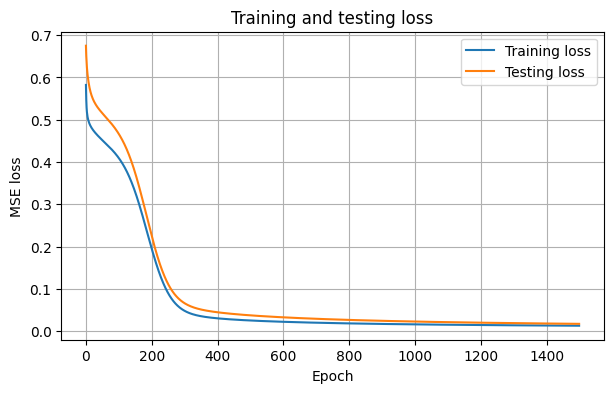

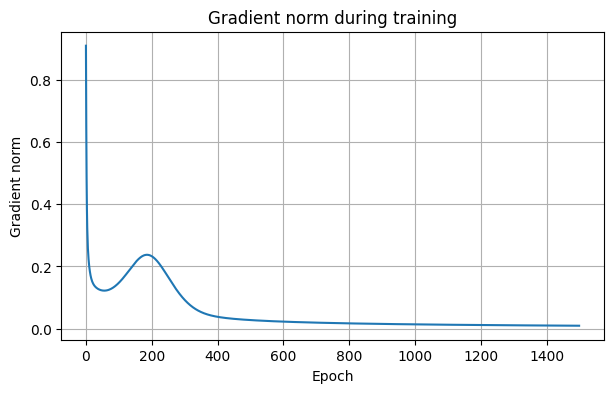

In [17]:

plt.figure()
plt.plot(history["epoch"], history["train_loss"], label="Training loss")
plt.plot(history["epoch"], history["test_loss"], label="Testing loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training and testing loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(history["epoch"], history["grad_norm"])
plt.xlabel("Epoch")
plt.ylabel("Gradient norm")
plt.title("Gradient norm during training")
plt.grid(True)
plt.show()



## 🔹 Visualize the Learned Function

The most intuitive diagnostic in a one-dimensional regression problem is the learned function itself.

We compare:
- the true function,
- the noisy data,
- the network prediction.

This connects the software workflow back to modeling interpretation.


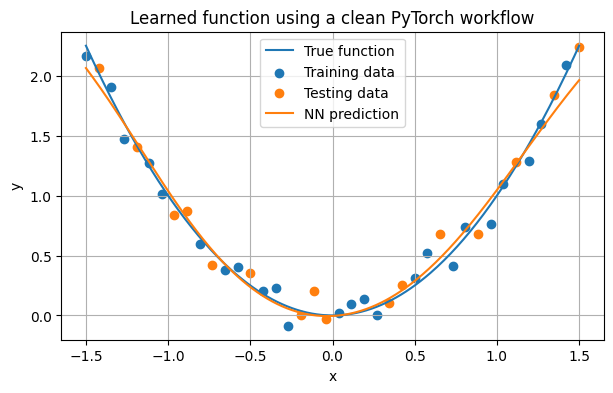

In [18]:

x_plot_raw = torch.linspace(-1.5, 1.5, 300).unsqueeze(1)
x_plot = (x_plot_raw - x_mean) / x_std
y_plot_true = x_plot_raw**2

model.eval()
with torch.no_grad():
    y_plot_pred = model(x_plot)

plt.figure()
plt.plot(x_plot_raw.numpy(), y_plot_true.numpy(), label="True function")
plt.scatter(x_train_raw.numpy(), y_train.numpy(), label="Training data")
plt.scatter(x_test_raw.numpy(), y_test.numpy(), label="Testing data")
plt.plot(x_plot_raw.numpy(), y_plot_pred.numpy(), label="NN prediction")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Learned function using a clean PyTorch workflow")
plt.legend()
plt.grid(True)
plt.show()



## 🔍 Sanity Check

At this point, verify the following:

- Is the training loss decreasing substantially?
- Is the testing loss of similar order to the training loss?
- Does the prediction capture the main quadratic trend?
- Is the model behavior smooth and reasonable?
- Are we normalizing inputs using training data statistics only?

These habits become even more important in realistic scientific ML workflows.



## 🔹 Why This Notebook Matters

This notebook is important because it marks a transition.

In the earlier notebooks, we focused on understanding the neural network mechanistically:
- one forward pass,
- one backward pass,
- one update,
- repeated updates.

Now we are practicing a more standard workflow that students will see in real research code.

However, the pedagogical priority remains the same:

> The code should never become detached from the mathematics.

If a student can run the notebook but cannot explain what `fc1`, `tanh`, and `fc2` mean in equations, then the abstraction has become too opaque.



## 🔹 Reflection Questions

1. Why is it useful to separate model definition, training, and evaluation into different components?
2. Why is input normalization often helpful for optimization?
3. Why must normalization parameters be computed from the training set only?
4. What additional information does the gradient norm provide beyond the loss curve?
5. In a larger engineering problem, what other best practices would you want to add?

These questions move students from code execution toward methodological thinking.



## 🧠 Engineering Takeaway

A standard PyTorch workflow is not just a programming convenience.

It supports better scientific practice by encouraging:
- modularity,
- reproducibility,
- cleaner debugging,
- clearer separation between training and evaluation.

At the same time, the essential modeling problem remains

$$
\hat{y} = f(x; \theta), \qquad \theta^\star = \arg\min_\theta L(\theta).
$$

The software gets cleaner, but the mathematical responsibility does not disappear.



## 🚀 Next

In the next notebook, we will shift from guided implementation to active reasoning.

Students will debug, modify, and interpret the behavior of neural networks themselves.

That final notebook is designed as an in-class exercise so that the emphasis is on:
- diagnosing problems,
- making design choices,
- explaining outcomes.
